# N13 — Padrões de Comunicação entre Agentes

* Professor: Julio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a>


## 0.1 Pré-requisitos

Para acompanhar este notebook, é esperado que você já tenha:

- construído os agentes especialistas (`create_agent`, ferramentas);
- usado `Command(goto=...)` para roteamento explícito em `StateGraph`;
- noções de reducers com `Annotated[list[X], ...]`;


## 0.2 Objetivos

Ao final deste notebook, você deverá saber:

1. Diferenciar quatro padrões de comunicação entre agentes: **memory**, **relay**, **report** e **debate**.
2. Implementar cada padrão "na mão", com `StateGraph` puro.
3. Reconhecer a mesma lógica implementada em um framework multiagente de mais alto nível, a **Eagle**.
4. Ler e construir um **logbook** — o registro ordenado de quem disse o quê — para depurar e explicar uma execução multiagente.
5. Escolher o padrão de comunicação adequado para um problema novo.


## 0.3 Mapa do notebook

Neste notebook, vamos construir progressivamente:

1. Por que a *topologia* da comunicação importa tanto quanto as capacidades de cada agente.
2. Padrão **memory** — agentes coordenam via estado/memória compartilhada, sem se falar diretamente.
3. Padrão **relay** — agentes falam em uma ordem fixa, repassando o bastão adiante.
4. Padrão **report** — um supervisor escolhe um agente por vez, que sempre retorna a ele.
5. Padrão **debate** — agentes defendem posições opostas até um moderador decidir.
6. Comparando os quatro padrões.

Para o padrão 4 (report), mostramos duas versões: uma **manual**, com `StateGraph` puro (como nos notebooks anteriores), e uma com a **Eagle**, um framework multiagente que encapsula essa mesma lógica. Para os padrões 2 e 3 (memory e relay), mostramos só a versão manual.

Para o padrão 5 (debate), mostramos só a versão manual — a Eagle não tem um equivalente pronto, e explicamos por quê.


## 0.4 Contexto usado nos exemplos

Continuamos com o mesmo elenco de agentes especialistas — `agente_tutor`, `agente_secretaria`, `agente_pesquisa` — mas agora o foco não é *quem* cada um é, e sim *como* eles se comunicam.

Além do LangGraph puro, a seção 4 (padrão *report*) usa a **Eagle** (*Enhanced Agents for Generative Language Excellence*).

A **Eagle** é um framework para orquestração de multiagente com modelos de linguagem construído sobre o próprio LangGraph. Esse framework é resultado de um projeto de pesquisa em um convênio entre a Unicamp e a Petrobras. 

Para os padrões *memory* e *relay*, não temos um exemplo Eagle validado, então essas duas seções ficam só na versão manual (LangGraph puro).

Para *report*, também não existe notebook de referência oficial. Diferente da seção de *relay*, o código Eagle da seção 4 foi escrito a partir da leitura do código-fonte da Eagle instalada, não de um exemplo testado -- ver a nota na seção 4.2 para os detalhes.

> **Aviso sobre versão:** a Eagle é um framework em desenvolvimento ativo, e sua API muda entre versões (o import do moderador de relay, por exemplo, já mudou de lugar em versões recentes do pacote publicado no PyPI). Se algum import falhar no seu ambiente, vale rodar `pip show dev-tools-eagle` e, se necessário, `import eagle; help(eagle.chat_schemas)` para localizar o caminho correto na sua versão instalada.

---

## 0.5 Preparação do ambiente


In [3]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
%pip install -U langgraph langchain langchain-ollama langchain-openai python-dotenv pydantic
%pip install -U dev-tools-eagle


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Imports usados ao longo da aula.

In [4]:
import operator
from typing import Annotated, Literal, TypedDict

from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import Command


Funções auxiliares de exibição, incluindo uma nova: `imprimir_logbook`, para mostrar de forma ordenada quem disse o quê durante uma execução multiagente.

In [5]:
from langgraph.graph.state import CompiledStateGraph
from IPython.display import Image, display, Markdown


def display_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


def print_last_message(result: dict) -> None:
    display(Markdown(result["messages"][-1].content))


def imprimir_logbook(logbook: list[dict]) -> None:
    """Imprime um logbook -- uma lista de {'agente': ..., 'conteudo': ...} -- em ordem."""
    print("=== Logbook ===")
    for entrada in logbook:
        print(f"[{entrada['agente']}] {entrada['conteudo']}")
    print("===============")


Inicializamos o modelo de linguagem, na mesma configuração usada nos notebooks anteriores.


In [6]:
# Reaproveite aqui a mesma configuração de LLM usada nos notebooks anteriores.
#llm = init_chat_model("ollama:llama3.2:3b", temperature=0)


import os

from dotenv import load_dotenv

load_dotenv()
print("Chave OPENAI_API_KEY configurada com sucesso." if "OPENAI_API_KEY" in os.environ else "Chave não encontrada.")

llm = init_chat_model("openai:gpt-4o-mini", temperature=0)



Chave OPENAI_API_KEY configurada com sucesso.


Reconstruímos os nossos agentes especialistas — mesmo cenário, mesmas ferramentas.

In [7]:
MODULOS_CURSO = {
    "A4": {"tema": "Ferramentas e create_agent", "duracao_horas": 6},
    "A5": {"tema": "Memória em LangGraph", "duracao_horas": 5},
    "A6": {"tema": "Memória Reflexiva", "duracao_horas": 4},
    "A7": {"tema": "Arquiteturas Multiagente", "duracao_horas": 6},
    "A8": {"tema": "Padrões de Comunicação entre Agentes", "duracao_horas": 6},
}

PRAZOS_CURSO = {
    "matricula": "até 20/08/2026",
    "trancamento": "até 30/09/2026",
    "certificado": "emitido em até 10 dias úteis após a conclusão do último módulo",
}

BASE_CONHECIMENTO = {
    "reducer": "Reducers controlam como o novo valor de um campo do estado se combina com o valor anterior a cada atualização.",
    "runnableconfig": "RunnableConfig carrega metadados de execução, como thread_id, acessíveis via config['configurable'].",
    "checkpointer": "Um checkpointer salva o estado inteiro do grafo a cada passo, associado a um thread_id — memória de curto prazo.",
    "store": "Um store guarda informação organizada em namespaces, acessível de qualquer thread — memória de longo prazo.",
}


def consultar_modulo(codigo_modulo: str) -> dict:
    """Retorna o tema e a carga horária de um módulo do curso, dado seu código (ex.: A6)."""
    return MODULOS_CURSO.get(codigo_modulo, {"erro": "módulo não encontrado"})


def consultar_prazo(tipo: str) -> str:
    """Consulta prazos administrativos do curso. tipo pode ser: matricula, trancamento ou certificado."""
    return PRAZOS_CURSO.get(tipo, "Prazo não encontrado. Fale diretamente com a secretaria.")


def emitir_declaracao(aluno: str, modulo_atual: str) -> str:
    """Emite uma declaração simples de matrícula ativa para o aluno."""
    return f"Declaração emitida: {aluno} está matriculado(a) e cursando o módulo {modulo_atual}."


def buscar_conceito(termo: str) -> str:
    """Busca a definição de um conceito técnico de LangGraph na base de conhecimento do curso."""
    termo_normalizado = termo.lower().strip()
    for chave, definicao in BASE_CONHECIMENTO.items():
        if chave in termo_normalizado or termo_normalizado in chave:
            return definicao
    return "Conceito não encontrado na base de conhecimento do curso."


agente_tutor = create_agent(
    model=llm,
    tools=[consultar_modulo],
    system_prompt=(
        "Você é o tutor técnico do curso de LangGraph. "
        "Responda apenas dúvidas sobre o conteúdo e a carga horária dos módulos."
    ),
)

agente_secretaria = create_agent(
    model=llm,
    tools=[consultar_prazo, emitir_declaracao],
    system_prompt=(
        "Você é a secretaria do curso de LangGraph. "
        "Responda apenas dúvidas administrativas: prazos, matrícula, certificado."
    ),
)

agente_pesquisa = create_agent(
    model=llm,
    tools=[buscar_conceito],
    system_prompt=(
        "Você é o agente de pesquisa conceitual do curso de LangGraph. "
        "Responda definições de conceitos técnicos gerais, sem falar de módulos específicos."
    ),
)


---

# 1. A topologia da comunicação importa

No Notebook 12, o foco era *quem* cada agente é (escopo, ferramentas, prompt). 

Neste notebook, o foco é *como* eles trocam informação — e essa escolha muda o comportamento do sistema tanto quanto a qualidade de cada agente individual.

Quatro formas comuns de organizar essa comunicação:

```text
MEMORY   tutor ⇄ [memória compartilhada] ⇄ secretaria ⇄ pesquisa
         (não conversam direto; leem e escrevem no mesmo "quadro")

RELAY    tutor → secretaria → pesquisa
         (falam em ordem fixa, um repassando pro próximo)

REPORT           ┌── tutor ──┐
         supervisor ── secretaria ──┤  (sempre volta pro supervisor)
                 └── pesquisa ─┘

DEBATE   agente A ⇄ agente B, com um moderador julgando ao final
         (mesma pergunta, posições opostas, várias rodadas)
```

Nenhum padrão é "melhor" em geral — cada um resolve um problema de coordenação diferente. 

As próximas seções constroem os quatro, sempre mostrando o grafo (a estrutura) e o **logbook** (o que de fato aconteceu numa execução).


---

# 2. Padrão Memory

Neste padrão, os agentes não trocam mensagem diretamente. Cada um lê o que já foi produzido por outros em uma **memória compartilhada** (um "quadro" comum) e adiciona sua própria contribuição — sem saber, necessariamente, quem escreveu o quê antes.

Cenário: os três especialistas colaboram para montar um **resumo de estudos** para um aluno, cada um contribuindo com sua parte, lendo o que os outros já escreveram.

## 2.1 Manual (LangGraph)

No LangGraph, isso é só mais um campo do estado — um "quadro" que todo nó pode ler e ao qual todo nó pode adicionar algo, via um reducer que concatena listas (`operator.add`).

In [9]:
class EstadoMemoriaCompartilhada(TypedDict):
    pedido: str
    quadro_compartilhado: Annotated[list[str], operator.add]
    logbook: Annotated[list[dict], operator.add]


def contribuir(agente_nome: str, agente, instrucao: str):
    """Fábrica de nó: um agente lê o quadro compartilhado e adiciona sua contribuição."""

    def no(state: EstadoMemoriaCompartilhada) -> dict:
        contexto_quadro = "\n".join(state["quadro_compartilhado"]) or "(quadro vazio até agora)"
        prompt = (
            f"{instrucao}\n\n"
            f"Pedido original do aluno: {state['pedido']}\n\n"
            f"O que já foi escrito no quadro compartilhado por outros agentes:\n{contexto_quadro}\n\n"
            "Adicione sua contribuição (1-2 frases), sem repetir o que já foi escrito."
        )
        resultado = agente.invoke({"messages": [{"role": "user", "content": prompt}]})
        contribuicao = resultado["messages"][-1].content

        return {
            "quadro_compartilhado": [f"({agente_nome}) {contribuicao}"],
            "logbook": [{"agente": agente_nome, "conteudo": contribuicao}],
        }

    return no


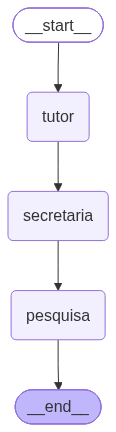

In [10]:
builder = StateGraph(EstadoMemoriaCompartilhada)

builder.add_node("tutor", contribuir("tutor", agente_tutor, "Contribua com o conteúdo técnico relevante."))
builder.add_node("secretaria", contribuir("secretaria", agente_secretaria, "Contribua com prazos ou informações administrativas relevantes."))
builder.add_node("pesquisa", contribuir("pesquisa", agente_pesquisa, "Contribua com um conceito geral relevante para o resumo."))

builder.add_edge(START, "tutor")
builder.add_edge("tutor", "secretaria")
builder.add_edge("secretaria", "pesquisa")
builder.add_edge("pesquisa", END)

grafo_memory_manual = builder.compile()
display_graph(grafo_memory_manual)


In [12]:
resultado = grafo_memory_manual.invoke({
    "pedido": "Preciso de um resumo de estudos sobre o módulo A6 antes da minha matrícula no A7.",
    "quadro_compartilhado": [],
    "logbook": [],
})

imprimir_logbook(resultado["logbook"])
print()
print("Quadro final:")
for linha in resultado["quadro_compartilhado"]:
    print("-", linha)


=== Logbook ===
[tutor] O módulo A6 aborda o tema "Memória Reflexiva" e tem uma carga horária de 4 horas. Este módulo é fundamental para desenvolver habilidades de autoavaliação e reflexão crítica sobre o aprendizado.
[secretaria] Para se matricular no módulo A7, é importante que você tenha concluído o módulo A6 e esteja atento aos prazos de matrícula, que geralmente ocorrem no final de cada módulo. Certifique-se de verificar as datas específicas para garantir sua inscrição a tempo.
[pesquisa] O módulo A6 também enfatiza a importância da metacognição, permitindo que os alunos compreendam melhor seus próprios processos de pensamento e aprendam a aplicar estratégias eficazes para otimizar seu aprendizado. Essa abordagem é essencial para preparar os alunos para os desafios do módulo A7.

Quadro final:
- (tutor) O módulo A6 aborda o tema "Memória Reflexiva" e tem uma carga horária de 4 horas. Este módulo é fundamental para desenvolver habilidades de autoavaliação e reflexão crítica sobre o

## Discussão (manual)

Repare que cada nó só recebe o `state["quadro_compartilhado"]` — nenhum deles chama outro diretamente, nem sabe que os outros dois existem como agentes. 

A coordenação acontece inteiramente através do que fica escrito no quadro. 

Isso é bem diferente do padrão *report* (seção 4), em que um supervisor decide explicitamente quem fala.


---

# 3. Padrão Relay

Neste padrão, os agentes falam em uma **ordem fixa**, cada um passando o "bastão" para o próximo — sem voltar a um supervisor entre as falas. 

É o padrão mais simples de coordenação explícita: útil quando as etapas têm uma sequência natural (ex.: gerar → revisar → aprovar).

Cenário: um checklist de boas-vindas para um aluno novo — o tutor explica o próximo módulo, a secretaria confirma a situação da matrícula, e a pesquisa complementa com um conceito-chave do módulo — sempre nessa ordem.

## 3.1 Manual (LangGraph)

Neste padrão, cada nó **repassa a saída do anterior como parte do seu próprio input**, em vez de trabalhar de forma isolada, e todos escrevem no mesmo `logbook`.

In [14]:
class EstadoRelay(TypedDict):
    pedido: str
    mensagem_atual: str
    logbook: Annotated[list[dict], operator.add]


def etapa_relay(agente_nome: str, agente, instrucao: str):
    """Fábrica de nó: recebe a mensagem do agente anterior e repassa adiante."""

    def no(state: EstadoRelay) -> dict:
        prompt = (
            f"{instrucao}\n\n"
            f"Pedido original: {state['pedido']}\n\n"
            f"Mensagem de quem falou antes de você: {state['mensagem_atual']}\n\n"
            "Responda de forma objetiva, como parte de uma sequência de boas-vindas."
        )
        resultado = agente.invoke({"messages": [{"role": "user", "content": prompt}]})
        resposta = resultado["messages"][-1].content

        return {
            "mensagem_atual": resposta,
            "logbook": [{"agente": agente_nome, "conteudo": resposta}],
        }

    return no


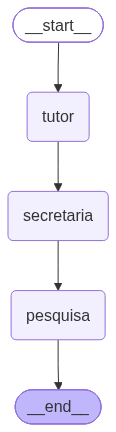

In [16]:
builder = StateGraph(EstadoRelay)

builder.add_node("tutor", etapa_relay("tutor", agente_tutor, "Explique brevemente o que o aluno vai estudar no próximo módulo (A7)."))
builder.add_node("secretaria", etapa_relay("secretaria", agente_secretaria, "Confirme o prazo de matrícula, dado o que o tutor acabou de explicar."))
builder.add_node("pesquisa", etapa_relay("pesquisa", agente_pesquisa, "Complemente com um conceito técnico relevante para o que já foi dito."))

builder.add_edge(START, "tutor")
builder.add_edge("tutor", "secretaria")
builder.add_edge("secretaria", "pesquisa")
builder.add_edge("pesquisa", END)

grafo_relay_manual = builder.compile()
display_graph(grafo_relay_manual)


In [17]:
resultado = grafo_relay_manual.invoke({
    "pedido": "Dar as boas-vindas a um aluno novo que vai começar o módulo A7.",
    "mensagem_atual": "",
    "logbook": [],
})

imprimir_logbook(resultado["logbook"])


=== Logbook ===
[tutor] Bem-vindo ao módulo A7! Neste módulo, você vai estudar "Arquiteturas Multiagente" e terá uma carga horária de 6 horas. Prepare-se para explorar como diferentes agentes podem interagir e colaborar em sistemas complexos!
[secretaria] O prazo de matrícula é até 20/08/2026. Aproveite seu aprendizado no módulo A7!
[pesquisa] Além disso, é importante lembrar que o aprendizado é um processo contínuo e dinâmico, onde a prática e a reflexão são fundamentais para a assimilação do conhecimento. Estamos aqui para apoiar sua jornada no módulo A7!


## Discussão (manual)

A estrutura é idêntica à do padrão *memory* (mesmos três nós em sequência) — a diferença está no que passa de um nó para o outro: aqui, cada agente recebe **diretamente** a saída do anterior (`mensagem_atual`), formando uma cadeia de repasse. 

No padrão *memory*, diferentemente, cada agente lê um "quadro" acumulado, não uma única mensagem do agente anterior.


---

# 4. Padrão Report

Neste padrão, um **supervisor** escolhe um agente por vez; o agente responde e **sempre volta direto ao supervisor**, que decide o próximo passo (chamar outro agente, ou encerrar). É uma topologia estrela: todo mundo fala só com o supervisor, nunca entre si.

Isso já apareceu no Notebook 12 (seção 6) — lá, por simplicidade, cada especialista ia direto para `END` depois de responder. 

Agora fechamos o ciclo: o especialista **volta ao supervisor**, que pode chamar outro agente antes de encerrar.

## 4.1 Manual (LangGraph)

In [9]:
class EstadoReport(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    logbook: Annotated[list[dict], operator.add]


class DecisaoSupervisor(BaseModel):
    proximo: Literal["tutor", "secretaria", "pesquisa", "fim"] = Field(
        description=(
            "Próximo agente a consultar, ou 'fim' se a pergunta já foi respondida "
            "de forma completa pelos agentes chamados até agora."
        )
    )


def supervisor(state: EstadoReport) -> Command[Literal["tutor", "secretaria", "pesquisa", "__end__"]]:
    roteador = llm.with_structured_output(DecisaoSupervisor)
    decisao = roteador.invoke([
        SystemMessage(content=(
            "Você coordena tutor (conteúdo dos módulos), secretaria (administrativo) e "
            "pesquisa (conceitos gerais). Decida o próximo agente a consultar, ou 'fim' "
            "se a resposta já está completa."
        )),
        *state["messages"],
    ])
    destino = "__end__" if decisao.proximo == "fim" else decisao.proximo
    return Command(goto=destino)


Cada especialista, depois de responder, **volta ao supervisor** — em vez de ir direto pra `END`.

In [10]:
def agente_report(agente_nome: str, agente):
    def no(state: EstadoReport) -> Command[Literal["supervisor"]]:
        resultado = agente.invoke({"messages": state["messages"]})
        resposta = resultado["messages"][-1].content
        return Command(
            goto="supervisor",
            update={
                "messages": [{"role": "assistant", "content": resposta, "name": agente_nome}],
                "logbook": [{"agente": agente_nome, "conteudo": resposta}],
            },
        )

    return no


no_tutor = agente_report("tutor", agente_tutor)
no_secretaria = agente_report("secretaria", agente_secretaria)
no_pesquisa = agente_report("pesquisa", agente_pesquisa)


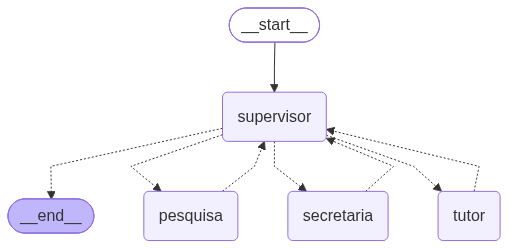

In [11]:
builder = StateGraph(EstadoReport)

builder.add_node("supervisor", supervisor)
builder.add_node("tutor", no_tutor)
builder.add_node("secretaria", no_secretaria)
builder.add_node("pesquisa", no_pesquisa)

builder.add_edge(START, "supervisor")

grafo_report_manual = builder.compile()
display_graph(grafo_report_manual)


Testamos com uma pergunta que toca dois assuntos — o supervisor deve conseguir consultar mais de um especialista antes de encerrar.

In [12]:
resultado = grafo_report_manual.invoke({
    "messages": [{"role": "user", "content": "Meu certificado vai citar o que é um checkpointer?"}],
    "logbook": [],
})

imprimir_logbook(resultado["logbook"])
print()
print_last_message(resultado)


=== Logbook ===
[pesquisa] Um checkpointer é um componente que salva o estado inteiro do grafo a cada passo, associado a um thread_id, funcionando como uma memória de curto prazo.



Um checkpointer é um componente que salva o estado inteiro do grafo a cada passo, associado a um thread_id, funcionando como uma memória de curto prazo.

## Discussão (manual)

Repare no grafo: diferente do Notebook 7 (seção 6), onde cada especialista tinha uma seta única para `END`, agora **todos os especialistas apontam de volta para o supervisor**, e é o supervisor quem decide ir para `END`. Essa é a diferença estrutural entre "supervisor decide uma vez" (N7) e "supervisor decide repetidamente até estar satisfeito" (padrão *report*).


## 4.2 Eagle: `ReportChatSchema`

Não temos, para este padrão, um notebook de workshop oficial como referência. O código abaixo foi escrito por mim a partir da leitura do código-fonte da Eagle instalada, não de um exemplo testado e fornecido pelo professor.

A classe usada como moderador aqui, `ReportModeratorReactPlanningAgent`, está de fato completa na versão instalada -- ao contrário do equivalente para relay, o refactor que consolidou a lógica de moderador dentro do React agent principal terminou o lado *report* (`observe`/`plan`/`execute` + os prompts que decidem entre continuar com um participante ou responder ao demandante).

**Sobre o nível de confiança:** verifiquei a implementação lendo o código-fonte (a classe existe, o `ReportChatSchema` sabe lidar com o campo `participant` que ela emite) -- mas não consegui, ao escrever este notebook, confirmar uma execução completa contra um LLM real (o Ollama local ficou instável durante a escrita). Rode a célula abaixo você mesmo: se funcionar, ótimo; se falhar, me mande o erro.

In [17]:
from eagle.chat_schemas.report_schemas.schemas import ReportChatSchema
from eagle.factories.agents import create_agent as create_eagle_agent


## Configuração dos agentes

Mesma estrutura de `*_config` usada nos outros padrões deste notebook: um LLM por etapa do ciclo cognitivo do agente (`observe_node_llm`, `plan_node_llm`, `execute_node_llm`).

In [18]:
moderator_report_config = {
    "agent_name": "Moderator",
    "agent_description": "Um supervisor que escolhe, a cada passo, qual especialista consultar sobre o curso de LangGraph.",
    "chat_history_window_size": 15,
    "observe_node_llm": llm,
    "observe_node_llm_use_structured_output": False,
    "plan_node_llm": llm,
    "plan_node_llm_use_structured_output": False,
    "execute_node_llm": llm,
    "execute_node_llm_use_structured_output": False,
}

tutor_report_config = {
    "agent_name": "Tutor",
    "agent_description": "Especialista em conteúdo técnico dos módulos do curso.",
    "chat_history_window_size": 15,
    "observe_node_llm": llm,
    "plan_node_llm": llm,
    "execute_node_llm": llm,
}

secretaria_report_config = tutor_report_config.copy()
secretaria_report_config["agent_name"] = "Secretaria"
secretaria_report_config["agent_description"] = "Especialista em questões administrativas: prazos, matrícula, certificado."

pesquisa_report_config = tutor_report_config.copy()
pesquisa_report_config["agent_name"] = "Pesquisa"
pesquisa_report_config["agent_description"] = "Especialista em conceitos gerais de LangGraph."


moderator_report = create_eagle_agent(name=moderator_report_config["agent_name"], description=moderator_report_config["agent_description"], agent_type="react", role="report_moderator")
tutor_report = create_eagle_agent(name=tutor_report_config["agent_name"], description=tutor_report_config["agent_description"], agent_type="react", role="agent")
secretaria_report = create_eagle_agent(name=secretaria_report_config["agent_name"], description=secretaria_report_config["agent_description"], agent_type="react", role="agent")
pesquisa_report = create_eagle_agent(name=pesquisa_report_config["agent_name"], description=pesquisa_report_config["agent_description"], agent_type="react", role="agent")


## Instanciando o `ReportChatSchema`

In [19]:
report_schema = ReportChatSchema(supervisor=moderator_report)

report_schema.add_agent(tutor_report)
report_schema.add_agent(secretaria_report)
report_schema.add_agent(pesquisa_report)


## Visualizando o schema

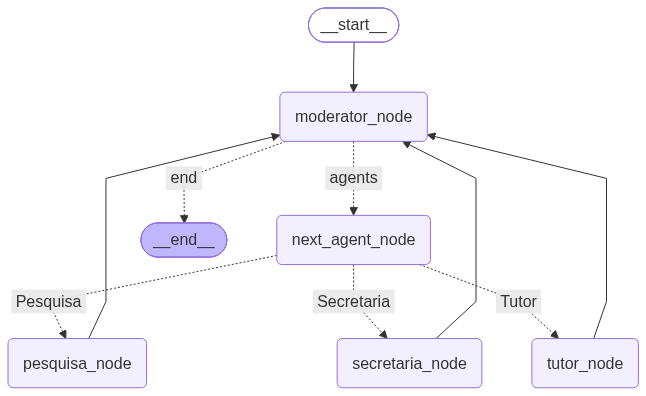

In [20]:
report_schema.compile()
report_schema._compiled_graph


## Estado inicial

Simula uma conversa entre o solicitante (aluno) e o Moderator, via `messages_with_requester`. Usamos de propósito uma pergunta que toca dois assuntos (conteúdo do módulo + o que consta no certificado), pra ver o supervisor consultar mais de um especialista antes de encerrar — a mesma pergunta usada na versão manual (seção 4.1).

In [21]:
initial_state_report = {
    "messages_with_requester": [
        {
            "role": "system",
            "name": "Moderator",
            "content": "Qual dúvida você tem hoje?",
        },
        {
            "role": "user",
            "name": "Aluno",
            "content": "Meu certificado vai citar o que é um checkpointer?",
        },
    ]
}


## Rodando o Report Schema

In [22]:
report_schema.run(
    state=initial_state_report,
    config={
        "agent_configs": {
            "Moderator": moderator_report_config,
            "Tutor": tutor_report_config,
            "Secretaria": secretaria_report_config,
            "Pesquisa": pesquisa_report_config,
        },
        "chat_name": "Dúvida sobre certificado e checkpointer",
    },
    store=None,
)


INFO:httpx:HTTP Request: POST http://localhost:11500/api/chat "HTTP/1.1 200 OK"


INFO:root:I don't need a feedback, proceeding to plan.
INFO:root:Event: {'observe_node': {'node_from': 'observe_node', 'i_need_a_feedback': False, 'execution_is_complete': False, 'observation': "A pergunta do aluno é sobre o certificado mencionar o termo 'checkpointer'. Como o Moderator, preciso determinar qual participante é mais adequado para responder. O termo 'checkpointer' parece estar relacionado a conceitos técnicos de LangGraph, o que sugere que o PARTICIPANTE 'Pesquisa' pode ter informações relevantes. Porém, se o certificado for uma questão administrativa, o PARTICIPANTE 'Secretaria' seria o mais adequado. Preciso investigar se 'checkpointer' é um conceito técnico ou administrativo antes de decidir a quem encaminhar a pergunta.", 'other_registers': {'node_paths_counter': {'observe_node_observe_node': 0, 'observe_node_plan_node': 0, 'observe_node_execute_node': 0, 'plan_node_observe_node': 0, 'plan_node_execute_node': 0, 'execute_node_observe_node': 0, 'execute_node_plan_node'

O **logbook** vem do `state_snapshot` — a conversa entre o moderador e o solicitante, e a conversa entre o moderador e os agentes (cada vez que o moderador escolhe um participante e recebe a resposta dele de volta).

In [23]:
state_snapshot_report = report_schema.state_snapshot

print("Chat entre o moderador e o solicitante:")
print("-------------------------------------------------")
for message in state_snapshot_report.values["messages_with_requester"]:
    print(f"{message.name}: {message.content}")

print("\n\nChat entre o moderador e os agentes:")
print("-------------------------------------------------")
for message in state_snapshot_report.values["messages_with_agents"]:
    print(f"{message.name}: {message.content}")


Chat entre o moderador e o solicitante:
-------------------------------------------------
Moderator: Qual dúvida você tem hoje?
Aluno: Meu certificado vai citar o que é um checkpointer?
Moderator: O termo 'checkpointer' no certificado do curso de LangGraph refere-se a um mecanismo utilizado para gerenciar e armazenar o estado de um fluxo de trabalho ou processo durante a execução de um gráfico de linguagem. Ele permite que o sistema 'salve' o progresso em determinados pontos críticos, facilitando a recuperação do estado anterior em caso de interrupções, falhas ou necessidade de continuação posteriormente. Isso é especialmente útil em aplicações que envolvem processos longos, complexos ou que exigem persistência de estado.


Chat entre o moderador e os agentes:
-------------------------------------------------
Moderator: O termo 'checkpointer' aparece no certificado do aluno. Pode explicar o que esse termo significa no contexto do curso de LangGraph?
Pesquisa: No contexto do curso de La

## Discussão (comparando)

| | Manual | Eagle |
|---|---|---|
| Quem decide o próximo agente | LLM com saída estruturada (`DecisaoSupervisor`), a cada volta ao supervisor | o moderador (`ReportModeratorReactPlanningAgent`) decide via `execute_node`, emitindo `participant` |
| Volta ao supervisor entre falas? | sim, via `Command(goto="supervisor")` em cada especialista | sim, é o comportamento nativo do `ReportChatSchema` |
| Detecção de falha de um participante | não tratada | herda o tratamento de `execution_is_complete` da base do `BasicChatSchema` |
| Esforço de implementação | baixo | médio (mais peças, ciclo cognitivo completo por agente) |

A versão manual já cobre bem o caso comum. A Eagle vale a pena pelo ciclo cognitivo padronizado por agente e pelo tratamento de falha embutido -- mas, ao contrário do padrão *relay* (seção 0.4), aqui não há nenhuma peça do framework faltando: o padrão está completo na versão instalada.


---

# 5. Padrão Debate

Neste padrão, dois agentes defendem posições **opostas** sobre a mesma pergunta, ao longo de várias rodadas, e um terceiro agente — o **moderador** — julga e sintetiza ao final. 

É útil quando não existe uma resposta unicamente correta, e o valor está em explorar os dois lados antes de decidir.

Tema do nosso debate: a própria discussão que fechou o Notebook 12 — **orquestrador (*subagents as tools*) vs. arquitetura de grafo explícita** — qual abordagem multiagente o assistente do curso deveria usar internamente.

```text
        pergunta
           │
     ┌─────┴─────┐
     ▼           ▼
 Agente A     Agente B      (rodada 1: cada um argumenta)
     │           │
     ▼           ▼
 Agente A     Agente B      (rodada 2: cada um rebate o outro)
     │           │
     └─────┬─────┘
           ▼
      Moderador             (julga e sintetiza)
```



## 5.1 Manual (LangGraph)

In [14]:
class EstadoDebate(TypedDict):
    tema: str
    argumentos_a: Annotated[list[str], operator.add]
    argumentos_b: Annotated[list[str], operator.add]
    rodada: int
    logbook: Annotated[list[dict], operator.add]


NUMERO_DE_RODADAS = 2

agente_pro_orquestrador = create_agent(
    model=llm,
    tools=[],
    system_prompt=(
        "Você defende que o assistente do curso deveria usar um ORQUESTRADOR "
        "(padrão subagents as tools: agentes especialistas viram ferramentas de um "
        "agente coordenador) em vez de uma arquitetura de grafo explícita. "
        "Argumente de forma objetiva, em 2-3 frases por rodada, rebatendo o outro lado "
        "quando houver argumentos anteriores."
    ),
)

agente_pro_grafo = create_agent(
    model=llm,
    tools=[],
    system_prompt=(
        "Você defende que o assistente do curso deveria usar uma ARQUITETURA DE GRAFO "
        "explícita (StateGraph com Command, nós visíveis) em vez de um orquestrador do "
        "tipo subagents as tools. Argumente de forma objetiva, em 2-3 frases por rodada, "
        "rebatendo o outro lado quando houver argumentos anteriores."
    ),
)

agente_moderador_debate = create_agent(
    model=llm,
    tools=[],
    system_prompt=(
        "Você modera um debate técnico. Ao final das rodadas, sintetize os melhores "
        "argumentos de cada lado e recomende quando usar cada abordagem -- sem "
        "declarar um vencedor absoluto, já que ambas têm méritos."
    ),
)


In [15]:
def montar_prompt(tema: str, lado: str, argumentos_proprios: list[str], argumentos_adversario: list[str]) -> str:
    historico_proprio = "\n".join(argumentos_proprios) or "(você ainda não argumentou)"
    historico_adversario = "\n".join(argumentos_adversario) or "(o outro lado ainda não argumentou)"
    return (
        f"Tema do debate: {tema}\n\n"
        f"Seus argumentos até agora:\n{historico_proprio}\n\n"
        f"Argumentos do outro lado até agora:\n{historico_adversario}\n\n"
        "Dê seu próximo argumento."
    )


def no_agente_a(state: EstadoDebate) -> dict:
    prompt = montar_prompt(state["tema"], "A", state["argumentos_a"], state["argumentos_b"])
    resultado = agente_pro_orquestrador.invoke({"messages": [{"role": "user", "content": prompt}]})
    argumento = resultado["messages"][-1].content
    return {
        "argumentos_a": [argumento],
        "logbook": [{"agente": "pro-orquestrador", "conteudo": argumento}],
    }


def no_agente_b(state: EstadoDebate) -> dict:
    prompt = montar_prompt(state["tema"], "B", state["argumentos_b"], state["argumentos_a"])
    resultado = agente_pro_grafo.invoke({"messages": [{"role": "user", "content": prompt}]})
    argumento = resultado["messages"][-1].content
    return {
        "argumentos_b": [argumento],
        "rodada": state["rodada"] + 1,
        "logbook": [{"agente": "pro-grafo", "conteudo": argumento}],
    }


def no_moderador(state: EstadoDebate) -> dict:
    transcricao = "\n".join(
        f"[Rodada {i+1}] Pró-orquestrador: {a}\nPró-grafo: {b}"
        for i, (a, b) in enumerate(zip(state["argumentos_a"], state["argumentos_b"]))
    )
    prompt = f"Tema: {state['tema']}\n\nTranscrição completa do debate:\n{transcricao}"
    resultado = agente_moderador_debate.invoke({"messages": [{"role": "user", "content": prompt}]})
    sintese = resultado["messages"][-1].content
    return {"logbook": [{"agente": "moderador", "conteudo": sintese}]}


def decidir_continuar(state: EstadoDebate) -> Literal["agente_a", "moderador"]:
    if state["rodada"] < NUMERO_DE_RODADAS:
        return "agente_a"
    return "moderador"


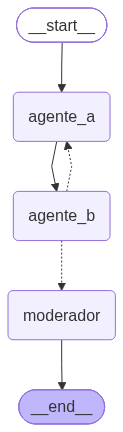

In [16]:
builder = StateGraph(EstadoDebate)

builder.add_node("agente_a", no_agente_a)
builder.add_node("agente_b", no_agente_b)
builder.add_node("moderador", no_moderador)

builder.add_edge(START, "agente_a")
builder.add_edge("agente_a", "agente_b")
builder.add_conditional_edges("agente_b", decidir_continuar, {"agente_a": "agente_a", "moderador": "moderador"})
builder.add_edge("moderador", END)

grafo_debate = builder.compile()
display_graph(grafo_debate)


In [17]:
resultado = grafo_debate.invoke({
    "tema": "Orquestrador (subagents as tools) vs. arquitetura de grafo explícita para o assistente do curso",
    "argumentos_a": [],
    "argumentos_b": [],
    "rodada": 0,
    "logbook": [],
})

imprimir_logbook(resultado["logbook"])


=== Logbook ===
[pro-orquestrador] Um orquestrador permite uma coordenação mais eficiente entre subagentes, pois centraliza a tomada de decisões e a alocação de tarefas, resultando em uma comunicação mais fluida e menos sobrecarga de informações. Isso facilita a adaptação e a escalabilidade do sistema, permitindo que novos subagentes sejam integrados sem a necessidade de reestruturar toda a arquitetura.
[pro-grafo] Embora um orquestrador centralizado possa parecer eficiente, uma arquitetura de grafo explícita oferece maior transparência e visibilidade sobre o fluxo de informações e decisões. Isso permite que os desenvolvedores e usuários compreendam melhor como as interações ocorrem, facilitando a identificação de gargalos e a otimização do sistema. Além disso, a estrutura de grafo pode ser mais intuitiva para a representação de estados e transições, promovendo uma melhor manutenção e evolução do assistente.
[pro-orquestrador] Embora a transparência de uma arquitetura de grafo explícit

## Discussão

O grafo tem um ciclo real: `agente_b` decide, via `add_conditional_edges`, se volta para `agente_a` (mais uma rodada) ou segue para `moderador` (encerrar). É estruturalmente parecido com o padrão *report* (o controle "orbita" um ponto central de decisão), mas aqui a decisão de continuar é uma regra simples (`rodada < NUMERO_DE_RODADAS`), não um LLM — poderia ser um LLM também, se quiséssemos que o próprio debate decidisse quando parar (ex.: "os dois lados já se repetiram, hora de encerrar").

Sobre a ausência de uma versão Eagle: isso não é uma limitação do LangGraph, é uma lacuna real e atual da Eagle como framework. Nada impede de **compor** um debate usando as peças que a Eagle já tem (`ReportChatSchema` alternando entre dois agentes por um número fixo de rodadas, com o moderador entrando na última) — mas isso seria você reconstruindo o padrão *debate* a partir de primitivas de *report*, não usando um `DebateChatSchema` pronto, porque ele não existe.


---

# 6. Comparando os quatro padrões

| | Memory | Relay | Report | Debate |
|---|---|---|---|---|
| Como a informação flui | via estado/memória compartilhada | em cadeia, ordem fixa | em estrela, sempre via supervisor | ida e volta entre 2 lados + moderador |
| Os agentes sabem uns dos outros? | não diretamente | só o próximo da fila | não — só o supervisor sabe de todos | sim, cada lado vê o argumento do outro |
| Quando usar | contribuições paralelas/independentes para um objetivo comum | etapas com sequência natural e fixa | perguntas que podem exigir mais de um especialista, decidido dinamicamente | questões sem resposta única, onde vale explorar dois lados |
| Versão Eagle testada neste notebook | não | não | sim, `ReportChatSchema` | não existe na Eagle |
| Visto pela primeira vez em | Notebook 5/6 (store) | Notebook 7 (roteamento trivial) | Notebook 7 (seção 6) | este notebook |

Os quatro padrões não são mutuamente exclusivos — sistemas reais costumam combinar mais de um (ex.: um *report* onde cada especialista também lê uma memória compartilhada).

**Nota sobre a coluna Eagle:** só o padrão *report* tem, neste notebook, uma versão Eagle -- construída a partir da leitura do código-fonte da Eagle instalada (seção 4.2). Para os demais padrões, optamos por não incluir código Eagle.


---

# 7. Exercícios de fixação

## Exercício 1 — Quarto agente no padrão memory

Adicione um `agente_boas_vindas` (do Notebook 7, exercício 1, se você já o criou) ao `grafo_memory_manual` da seção 2.1, contribuindo com o quadro compartilhado antes dos outros três.

## Exercício 2 — Relay com ordem dinâmica

Modifique o `grafo_relay_manual` da seção 3.1 para que a ordem dos três agentes seja decidida por um LLM no início (via saída estruturada), em vez de fixa no `add_edge`.

## Exercício 3 — Limitando rodadas no report

No `grafo_report_manual` da seção 4.1, adicione um contador de rodadas ao estado e force o encerramento (`Command(goto="__end__")`) depois de 4 consultas a especialistas, mesmo que o supervisor não tenha decidido "fim" — uma salvaguarda contra loops longos demais.

## Exercício 4 — Debate decidido por LLM

No `grafo_debate` da seção 5.1, troque a função `decidir_continuar` (hoje baseada em contagem de rodadas) por uma decisão de LLM: o próprio `agente_moderador_debate` decide, a cada rodada, se os argumentos já se repetiram o suficiente para encerrar.

## Exercício 5 — Qual padrão usar?

Para cada situação abaixo, diga qual dos quatro padrões (memory, relay, report, debate) você usaria, e por quê:

1. Três agentes revisam o mesmo texto, cada um focado em um critério diferente (gramática, clareza, tom), sem precisar ver o que os outros escreveram até o final.
2. Um agente gera código, outro escreve testes para esse código, um terceiro roda os testes e reporta o resultado — sempre nessa ordem.
3. Um assistente de compras precisa decidir, pergunta a pergunta, se consulta o agente de frete, o de pagamento ou o de catálogo.
4. Dois agentes representam posições políticas diferentes sobre uma política pública, e um terceiro resume o debate para um cidadão decidir sozinho.

## Exercício 6 — Eagle na sua máquina

Rode `pip show dev-tools-eagle` no seu ambiente e confirme a versão instalada. Se algum import da Eagle usado neste notebook falhar, use `import eagle.chat_schemas as cs; help(cs)` (ou `dir(cs)`) para localizar o caminho correto na sua versão, e anote a diferença.

---

# 8. Resumo da aula

Neste notebook, exploramos quatro padrões de comunicação entre agentes:

- **memory**: agentes coordenam via um estado/memória compartilhada, sem se falar diretamente — construído manualmente, via um campo do `state`;
- **relay**: agentes falam em ordem fixa, repassando adiante — manualmente, um pipeline sequencial;
- **report**: um supervisor escolhe um agente por vez, que sempre retorna a ele — manualmente, `Command(goto="supervisor")` em cada especialista, e também com a Eagle (`ReportChatSchema`), a partir da leitura do código-fonte da Eagle instalada (ver seção 4.2);
- **debate**: dois agentes argumentam posições opostas por várias rodadas, um moderador sintetiza — só manual.

Em todos os casos, usamos um **logbook** — o registro ordenado de quem falou o quê — como ferramenta central para depurar e explicar uma execução multiagente, além do grafo mostrando a estrutura.

Um ponto metodológico importante desta aula: só incluímos código Eagle onde a leitura do código-fonte deu confiança suficiente para apresentá-lo como validado — para os demais padrões, preferimos deixar a lacuna explícita a arriscar uma integração não verificada.

## 8.1 Checklist de compreensão

Antes de seguir, você deve conseguir responder:

1. No padrão *memory*, por que os agentes não precisam saber uns dos outros para colaborar?
2. Qual a diferença estrutural entre o padrão *relay* e o padrão *report* — quem fala com quem?
3. Por que o padrão *report* deste notebook é tão parecido com a arquitetura de grafo do Notebook 7?
4. Por que este notebook mostra código Eagle só para o padrão *relay*, e não para *memory* e *report*?
5. Para que serve um logbook, além de mostrar o grafo da execução?


## 8.2 Próximos passos

A partir daqui, os próximos passos naturais são:

- combinar padrões — por exemplo, um *report* onde cada especialista também lê uma memória compartilhada (seção 2);
- adicionar memória de longo prazo (Notebooks 5 e 6) a qualquer um desses padrões, para que decisões de coordenação também sejam lembradas entre execuções diferentes;
- explorar `human-in-the-loop` como um "agente" a mais em qualquer um dos quatro padrões — por exemplo, um humano como moderador no padrão *debate*.


# 9. Referências

- LangGraph — `Command` e controle de fluxo: https://reference.langchain.com/python/langgraph/types/#langgraph.types.Command
- LangChain — Multi-agent (subagents as tools): https://docs.langchain.com/oss/python/langchain/multi-agent/subagents-personal-assistant
- Eagle — pacote no PyPI: https://pypi.org/project/dev-tools-eagle/
- Multi-Agent Debate como técnica de raciocínio: Du et al., "Improving Factuality and Reasoning in Language Models through Multiagent Debate" — https://arxiv.org/abs/2305.14325
